# Supplementary Figure S6: analog secondary structure & HydrAMP comparison

Combined figure (≤ 6.5 × 8 in, min font 6 pt):

- **Panel A** — α-helix fraction in SDS micelles by prototype family (BeStSel fits of CD spectra). Each family row shows its prototype as a coloured diamond and analogs as dots; leads are black-outlined with Ω-family-letter-number callouts; a *de novo* reference row sits on top. Kruskal–Wallis test with η² effect size in the corner. *(was Figure S4 panel D)*
- **Panels B–C** — OmegAMP-A vs HydrAMP-A analog success rate (fraction reaching MIC ≤ threshold) for *E. coli* and *S. aureus*. HydrAMP MICs converted µg/mL → µM via sequence MW. *(was Figure S6)*

In [1]:
#!/usr/bin/env python
# coding: utf-8
"""Combined figure: S4D (alpha-helix fraction by prototype family) on top,
S6 (OmegAMP vs HydrAMP analog success rate, per species) below."""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
from scipy.stats import kruskal

warnings.filterwarnings("ignore")

DATA = Path("/home/pszymczak/code/omegamp-dashboard/data")
BENCH = Path("/home/pszymczak/code/omegamp-dashboard/benchmark")
OUT = Path("/home/pszymczak/code/omegamp-dashboard/figures")
OUT.mkdir(parents=True, exist_ok=True)

matplotlib.font_manager._load_fontmanager(try_read_cache=False)
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "axes.edgecolor": "#333333",
    "xtick.color": "#333333", "ytick.color": "#333333",
    "axes.labelcolor": "#222222",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "figure.dpi": 300, "savefig.dpi": 600,
    "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "xtick.major.pad": 2, "ytick.major.pad": 2,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})


In [2]:
# ── Load data and derive family assignments ──────────────────────────────────
ref = pd.read_csv(DATA / "omegamp_reference_table.csv")
mic = pd.read_csv(DATA / "mic.csv")
bestsel = pd.read_csv(DATA / "bestsel.csv")
_dc = lambda v: float(str(v).lstrip(">")) if pd.notna(v) else float("nan")
for _c in mic.columns[1:]:
    mic[_c] = mic[_c].apply(_dc)

PROTO_MAP = {"DBAASPS_20015": "As-CATH4-6L", "DBAASPS_20955": "OP-145-TII4"}

def resolve_family(row):
    if row["category"] == "prototype":
        return row["short_name"]
    p = str(row.get("prototype", ""))
    return PROTO_MAP.get(p, p) if p != "nan" else ""

ref["family"] = ref.apply(resolve_family, axis=1)
antimicrobial = ref[(ref["category"] == "analog")
                    & (ref["objective"] == "antimicrobial")].copy()
protos = ref[ref["category"] == "prototype"].set_index("family")

INACTIVE_ORDER = ["Mammutin-1", "GQ20", "As-CATH4-6L", "BoCo1",
                  "DeNo1047", "OP-145-TII4"]
FC = {"Mammutin-1": "#D55E00", "GQ20": "#E69F00", "BoCo1": "#009E73",
      "DeNo1047": "#56B4E9", "As-CATH4-6L": "#0072B2",
      "OP-145-TII4": "#CC79A7"}
LEADS_SET = {"Ω-AT-BoCo1-5", "Ω-AT-BoCo1-9",
             "Ω-AU-GQ20-4", "Ω-AP-Mammutin-1-4"}

LEAD_HELIX_OFFSETS = {
    "Ω-AT-BoCo1-5":      (10,  10),
    "Ω-AT-BoCo1-9":      (10, -10),
    "Ω-AU-GQ20-4":       (-10, 10),
    "Ω-AP-Mammutin-1-4": (10,  10),
}


In [3]:
# ── Panel A: alpha-helix fraction in SDS by prototype family ──────────────────
def draw_helix_panel(ax):
    bs = bestsel.merge(
        ref[["short_name", "category", "family", "objective"]],
        on="short_name", how="left",
    )
    ana = bs[(bs["category"] == "analog")
             & (bs["objective"] == "antimicrobial")].copy()
    dn = bs[bs["category"] == "de_novo"]

    fam_order = INACTIVE_ORDER[::-1]  # bottom-to-top

    dn_y = len(fam_order)
    dn_jit = np.random.RandomState(17).normal(0, 0.10, len(dn))
    ax.scatter(dn["fH_SDS_H2O"].values, dn_y + dn_jit,
               c="#888888", s=7, alpha=0.5, edgecolors="none", zorder=3)

    dn_med = dn["fH_SDS_H2O"].median()
    ax.axvline(dn_med, color="#ccc", ls=":", lw=0.5, zorder=1)

    groups = []
    for i, fam in enumerate(fam_order):
        fd = ana[ana["family"] == fam]
        color = FC[fam]
        if len(fd) == 0:
            continue

        if fam in protos.index:
            pname = protos.loc[fam, "short_name"]
            p_helix = bestsel.loc[bestsel["short_name"] == pname, "fH_SDS_H2O"]
            if len(p_helix) > 0:
                ax.scatter(p_helix.values[0], i, marker="D", c=color,
                           edgecolors="none", s=18, zorder=5)

        groups.append(fd["fH_SDS_H2O"].dropna().values)
        jit = np.random.RandomState(100 + i).normal(0, 0.10, len(fd))
        for j, (_, row) in enumerate(fd.iterrows()):
            is_lead = row["short_name"] in LEADS_SET
            if is_lead:
                ax.scatter(row["fH_SDS_H2O"], i + jit[j], c=color, s=14,
                           edgecolors="black", linewidth=0.5, zorder=5)
                idx = row["short_name"].split("-")[-1]
                fam_letter = fam[0]
                short_lab = f"Ω-{fam_letter}-{idx}"
                off = LEAD_HELIX_OFFSETS.get(row["short_name"], (10, 10))
                ha = "right" if off[0] < 0 else "left"
                ax.annotate(short_lab, (row["fH_SDS_H2O"], i + jit[j]),
                            xytext=off, textcoords="offset points",
                            fontsize=6, ha=ha, va="center", color="black",
                            arrowprops=dict(arrowstyle="-", color="#555", lw=0.5),
                            zorder=10)
            else:
                ax.scatter(row["fH_SDS_H2O"], i + jit[j], c=color, s=12,
                           marker="o", edgecolors="none", alpha=0.7, zorder=3)

    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        H, p = kruskal(*groups)
        n_total = sum(len(g) for g in groups)
        eta2 = H / (n_total - 1)
        ax.set_title(f"KW $p$ = {p:.1e}, $\\eta^2$ = {eta2:.2f}",
                     loc="right", fontsize=6, color="#555",
                     fontweight="bold", pad=2)

    ax.set_yticks(list(range(len(fam_order))) + [len(fam_order)])
    ylabs = ax.set_yticklabels(fam_order + ["$\\it{De\\;novo}$"], fontsize=6)
    for y_obj, f in zip(ylabs[:-1], fam_order):
        y_obj.set_color(FC[f])
    ylabs[-1].set_color("#666")
    ax.set_xlabel("α-helix fraction in SDS (%)", fontsize=6)
    ax.set_xlim(-2, 105)
    ax.set_ylim(-0.6, len(fam_order) + 0.6)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


In [4]:
# ── HydrAMP / OmegAMP analog data (panels B, C) ───────────────────────────────
_AA_MASS = {
    "A": 71.0788, "R": 156.1875, "N": 114.1038, "D": 115.0886, "C": 103.1388,
    "Q": 128.1307, "E": 129.1155, "G": 57.0519, "H": 137.1411, "I": 113.1594,
    "L": 113.1594, "K": 128.1741, "M": 131.1926, "F": 147.1766, "P": 97.1167,
    "S": 87.0782, "T": 101.1051, "W": 186.2132, "Y": 163.1760, "V": 99.1326,
}
def seq_mw_kda(seq):
    if not isinstance(seq, str) or not any(c.isalpha() for c in seq):
        return 2.0
    return (sum(_AA_MASS.get(aa, 111.1) for aa in seq.upper() if aa.isalpha()) + 18.0153) / 1000

analogs = ref[ref["category"] == "analog"]
mic_an = mic[mic["short_name"].isin(analogs["short_name"])]
n_omega = len(mic_an)

ecoli_cols = [c for c in mic.columns[1:] if "E. coli" in c and "K-12" not in c
              and c not in ["n_strains_le2", "n_strains_le4", "mic50", "min_mic"]]
saur_cols = [c for c in mic.columns[1:] if "S. aureus" in c
             and c not in ["n_strains_le2", "n_strains_le4", "mic50", "min_mic"]]

omega_ecoli = mic_an[ecoli_cols].astype(float).min(axis=1)
omega_saur = mic_an[saur_cols].astype(float).min(axis=1)

hydramp = pd.read_csv(BENCH / "hydramp.csv")
h_analogs = hydramp[~hydramp["peptide_id"].str.startswith("HydrAMP-Unc")].copy()
mw_map = (h_analogs.drop_duplicates("peptide_id")
                   .set_index("peptide_id")["sequence"].map(seq_mw_kda))
exact = h_analogs[h_analogs["mic_relation"] == "="].copy()
exact["mic_uM"] = exact.apply(lambda r: r["mic"] / mw_map.get(r["peptide_id"], 2.0), axis=1)
n_hydra = h_analogs["peptide_id"].nunique()

hydra_ecoli = (exact[exact["strain"].str.contains("coli", case=False)]
               .groupby("peptide_id")["mic_uM"].min())
hydra_saur = (exact[exact["strain"].str.contains("aureus", case=False)]
              .groupby("peptide_id")["mic_uM"].min())

thresholds = [0.5, 1, 2, 4, 8, 16, 32, 64, 128]
tick_labels = ["0.5", "1", "2", "4", "8", "16", "32", "64", "128"]

species = [
    ("$\\it{E. coli}$",   omega_ecoli, hydra_ecoli, f"{len(ecoli_cols)} strains", "2 strains"),
    ("$\\it{S. aureus}$", omega_saur,  hydra_saur,  f"{len(saur_cols)} strains", "1 strain"),
]

def draw_species_panel(ax, title, omega_best, hydra_best, omega_note, hydra_note):
    omega_rates = [(omega_best <= t).sum() / n_omega * 100 for t in thresholds]
    hydra_rates = [(hydra_best <= t).sum() / n_hydra * 100 for t in thresholds]
    ax.plot(thresholds, omega_rates, "o-", color="#EE7733", ms=3, lw=1.5,
            label=f"OmegAMP-A (n={n_omega}, {omega_note})", zorder=5)
    ax.plot(thresholds, hydra_rates, "s--", color="#228833", ms=3, lw=1.0,
            label=f"HydrAMP-A (n={n_hydra}, {hydra_note})", zorder=4)
    ax.set_xscale("log", base=2)
    ax.set_xticks(thresholds)
    ax.set_xticklabels(tick_labels, fontsize=6)
    ax.set_xlabel("MIC threshold (µM)", fontsize=6)
    ax.set_title(title, fontsize=7, pad=4)
    ax.set_ylim(-2, 105)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    leg = ax.legend(fontsize=6, loc="upper left", frameon=True,
                    framealpha=0.9, edgecolor="#cccccc")
    leg.get_frame().set_facecolor("white")


figure size (in): 6.50 x 5.00
OmegAMP analogs: 109 | HydrAMP analogs: 26
saved: /home/pszymczak/code/omegamp-dashboard/figures/figureS6_analog_hydramp.png
saved: /home/pszymczak/code/omegamp-dashboard/figures/figureS6_analog_hydramp.pdf


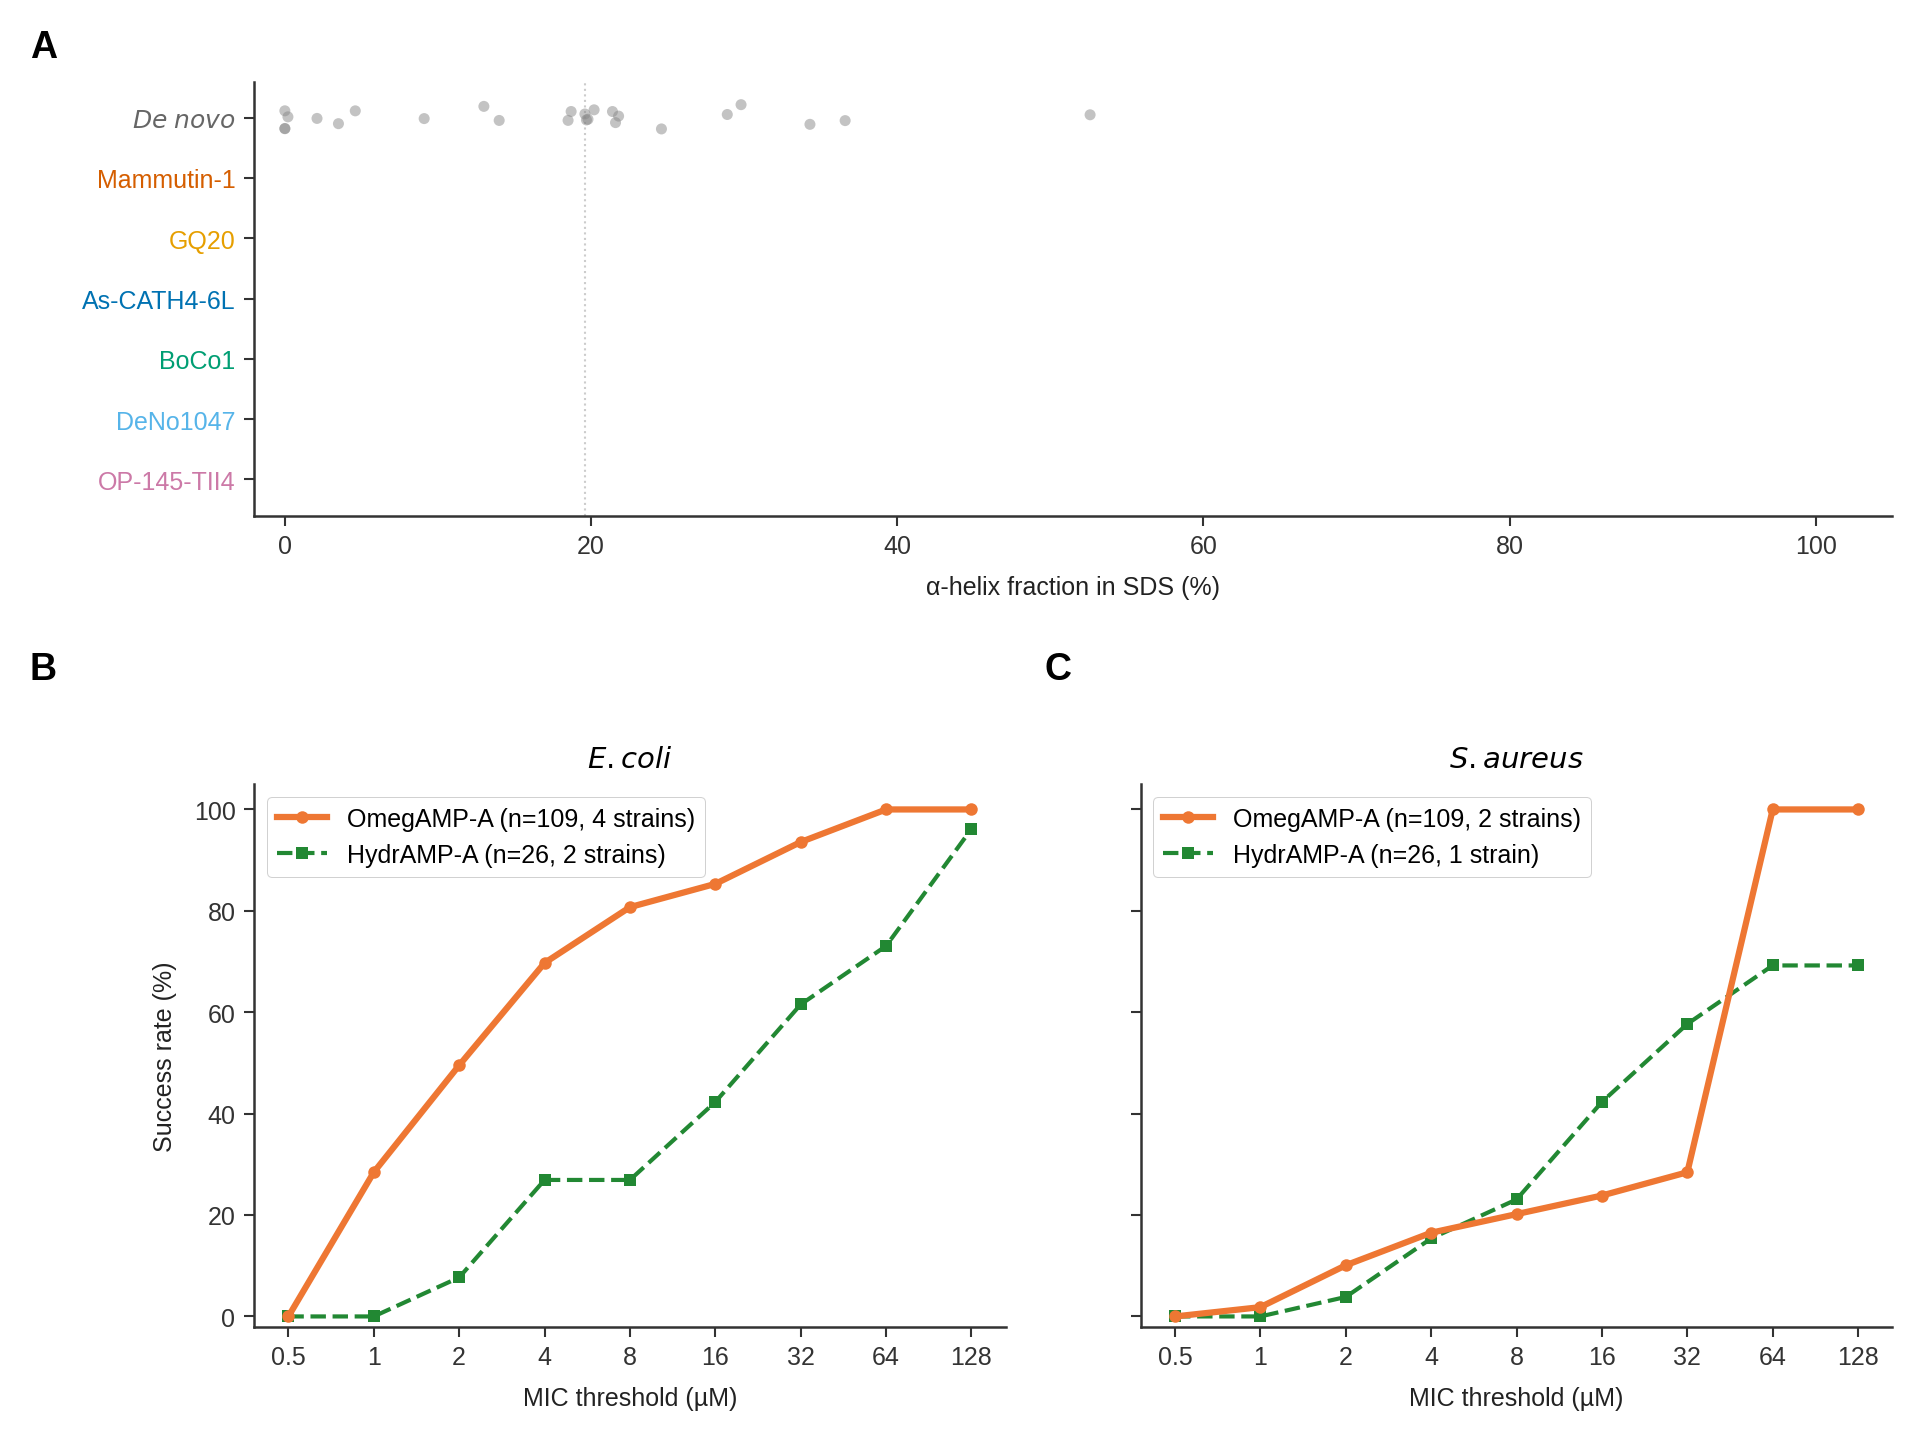

In [5]:
# ── Assemble the combined figure ──────────────────────────────────────────────
fig = plt.figure(figsize=(6.5, 5.0))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    height_ratios=[1.0, 1.25],
    hspace=0.55, wspace=0.18,
    left=0.13, right=0.97, top=0.93, bottom=0.10,
)

L = dict(fontsize=9, fontweight="bold", va="top", ha="left")

ax_a = fig.add_subplot(gs[0, :])
draw_helix_panel(ax_a)
fig.text(0.015, 0.965, "A", **L)

ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1], sharey=ax_b)
draw_species_panel(ax_b, *species[0])
draw_species_panel(ax_c, *species[1])
ax_b.set_ylabel("Success rate (%)", fontsize=6)
plt.setp(ax_c.get_yticklabels(), visible=False)

fig.text(0.015, 0.55, "B", **L)
fig.text(0.535, 0.55, "C", **L)

out_png = OUT / "figureS6_analog_hydramp.png"
out_pdf = OUT / "figureS6_analog_hydramp.pdf"
fig.savefig(out_png, dpi=400, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
bb = fig.get_size_inches()
print(f"figure size (in): {bb[0]:.2f} x {bb[1]:.2f}")
print(f"OmegAMP analogs: {n_omega} | HydrAMP analogs: {n_hydra}")
print(f"saved: {out_png}")
print(f"saved: {out_pdf}")
plt.show()
